## Notebook 15 - Shape of the Player Centrality Distribution
Núria Pascual Salas

**Question:** What shape does the distribution of player centrality (PageRank) have, and
does it vary across teams?

**Motivation:** Notebook 15 summarised each team's centrality distribution with two
scalars (entropy $S$, effective number $N_{\mathrm{eff}}$). This notebook looks at the
distribution itself: its form, its asymmetry, and which theoretical family it resembles.

**Two levels:**
1. **Pooled** (all player-team PageRank values together): large enough to fit candidate
   distributions and run goodness-of-fit tests.
2. **Per team** ($N \approx 25$–40): too small to fit distributions, but used to measure
   shape (skewness) and relate it to entropy and fragility.

**Candidate distributions:** log-normal, gamma, exponential, normal. A power-law is not
considered: PageRank sums to 1 and has a bounded, strictly positive support (no isolated
nodes), so it lacks the long unbounded tail a power-law would require.

**Inputs:** utils.py, LaLiga ZIP

**Outputs:**
- outputs/csv/centrality_shape_per_team.csv
- outputs/figures/centrality_distribution_aggregated.png
- outputs/figures/centrality_shape_vs_entropy_fragility.png

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Build the network

In [2]:
pagerank_by_team = {}   # team -> np.array of player PageRank values
for team_id, team_name in all_teams.items():
    G, n_matches = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    if G.number_of_nodes() == 0:
        continue
    pr = nx.pagerank(G, weight='weight')
    pagerank_by_team[team_name] = np.array(list(pr.values()))
    print(f"{team_name:18s} | {len(pr):3d} players")

all_pr = np.concatenate(list(pagerank_by_team.values()))
print(f"\nPooled sample: {len(all_pr)} player-team PageRank values")

Deportivo Alavés   |  29 players
Granada            |  40 players
Barcelona          |  29 players
Almería            |  35 players
Sevilla            |  35 players
Cádiz              |  33 players
Girona             |  25 players
Athletic Club      |  27 players
Real Sociedad      |  31 players
Mallorca           |  25 players
Real Betis         |  35 players
Atlético Madrid    |  27 players
Villarreal         |  32 players
Celta Vigo         |  31 players
Valencia           |  30 players
Las Palmas         |  29 players
Osasuna            |  29 players
Real Madrid        |  27 players
Getafe             |  32 players
Rayo Vallecano     |  26 players

Pooled sample: 607 player-team PageRank values


### 2. Aggregated distribution: describe and visualise

In [3]:
pr_rescaled = np.concatenate([
    v / v.mean() for v in pagerank_by_team.values()
])

print('Aggregated (mean-rescaled) PageRank distribution:')
print(f"  n          = {len(pr_rescaled)}")
print(f"  mean       = {pr_rescaled.mean():.3f}")
print(f"  median     = {np.median(pr_rescaled):.3f}")
print(f"  std        = {pr_rescaled.std():.3f}")
print(f"  skewness   = {stats.skew(pr_rescaled):+.3f}   (0 = symmetric, >0 = right tail)")
print(f"  kurtosis   = {stats.kurtosis(pr_rescaled):+.3f}   (excess; 0 = normal)")
print(f"  min, max   = {pr_rescaled.min():.3f}, {pr_rescaled.max():.3f}")

Aggregated (mean-rescaled) PageRank distribution:
  n          = 607
  mean       = 1.000
  median     = 0.882
  std        = 0.721
  skewness   = +0.842   (0 = symmetric, >0 = right tail)
  kurtosis   = +0.249   (excess; 0 = normal)
  min, max   = 0.150, 3.676


### 3. Fit candidate distributions and compare by AIC + KS


In [4]:
data = pr_rescaled
candidates = {
    'lognormal':   stats.lognorm,
    'gamma':       stats.gamma,
    'exponential': stats.expon,
    'normal':      stats.norm,
}

fit_results = []
for name, dist in candidates.items():
    params = dist.fit(data)
    ll = np.sum(dist.logpdf(data, *params))
    k = len(params)
    aic = 2 * k - 2 * ll
    ks_stat, ks_p = stats.kstest(data, dist.cdf, args=params)
    fit_results.append({
        'distribution': name,
        'n_params':     k,
        'loglik':       round(ll, 1),
        'AIC':          round(aic, 1),
        'KS_stat':      round(ks_stat, 4),
        'KS_p':         round(ks_p, 4),
    })

df_fit = pd.DataFrame(fit_results).sort_values('AIC').reset_index(drop=True)
df_fit['delta_AIC'] = (df_fit['AIC'] - df_fit['AIC'].min()).round(1)
print(df_fit.to_string(index=False))
print(f"\nBest fit by AIC: {df_fit.iloc[0]['distribution']}")

distribution  n_params  loglik    AIC  KS_stat   KS_p  delta_AIC
       gamma         3  -499.2 1004.4   0.0999 0.0000        0.0
 exponential         2  -508.4 1020.7   0.0900 0.0001       16.3
   lognormal         3  -574.6 1155.2   0.1031 0.0000      150.8
      normal         2  -662.8 1329.6   0.1192 0.0000      325.2

Best fit by AIC: gamma


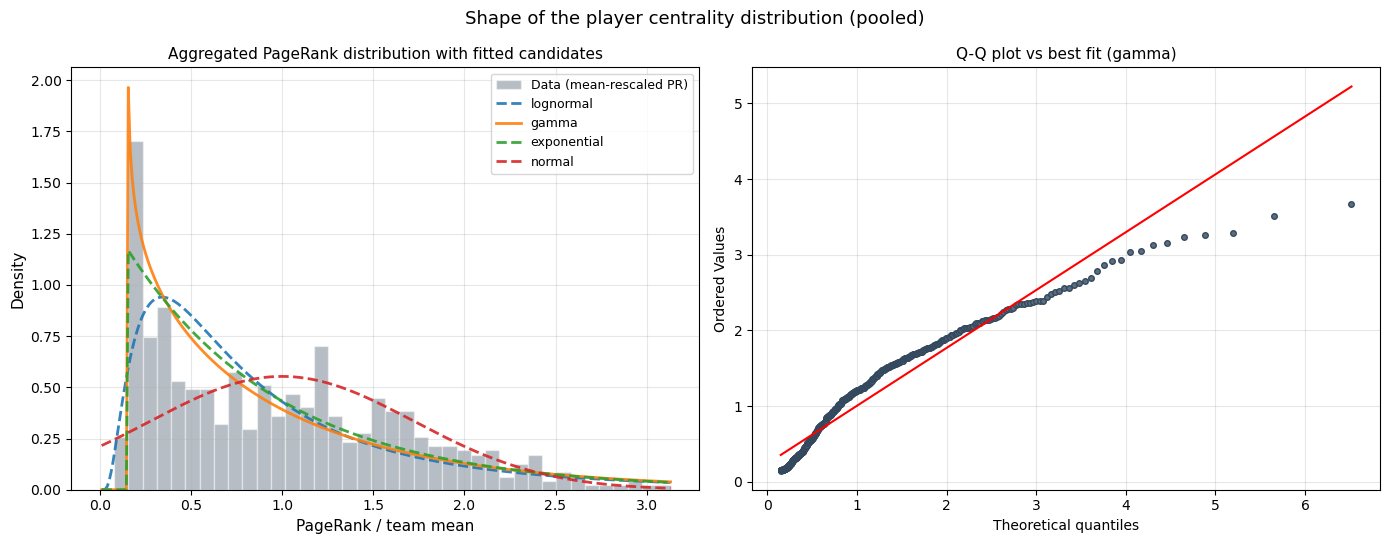

In [5]:
# Visualise: histogram + best-fit overlays + Q-Q plot vs best candidate
best_name = df_fit.iloc[0]['distribution']
best_dist = candidates[best_name]
best_params = best_dist.fit(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) histogram with fitted curves
ax = axes[0]
ax.hist(data, bins=40, density=True, alpha=0.45, color='#5d6d7e',
        edgecolor='white', label='Data (mean-rescaled PR)',
        range=(0, np.percentile(data, 99)))   # retalla l'1% superior
x = np.linspace(0.01, np.percentile(data, 99), 300)   # evita loc artificial
for name, dist in candidates.items():
    params = dist.fit(data)
    ax.plot(x, dist.pdf(x, *params), linewidth=2, label=name,
            linestyle='-' if name == best_name else '--', alpha=0.9)
ax.set_xlabel('PageRank / team mean', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Aggregated PageRank distribution with fitted candidates', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# (b) Q-Q plot vs best candidate
ax = axes[1]
stats.probplot(data, dist=best_dist, sparams=best_params, plot=ax)
ax.set_title(f'Q-Q plot vs best fit ({best_name})', fontsize=11)
ax.get_lines()[0].set_markerfacecolor('#5d6d7e')
ax.get_lines()[0].set_markeredgecolor('#34495e')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('red')
ax.grid(alpha=0.3)

plt.suptitle('Shape of the player centrality distribution (pooled)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/centrality_distribution_aggregated.png', dpi=130, bbox_inches='tight')
plt.show()

### 4. Per-team shape: skewness and kurtosis

In [6]:
shape_rows = []
for team, v in pagerank_by_team.items():
    shape_rows.append({
        'team':       team,
        'n_players':  len(v),
        'skewness':   stats.skew(v),
        'kurtosis':   stats.kurtosis(v),
        'cv':         v.std() / v.mean(),  
    })
df_shape = pd.DataFrame(shape_rows).round(3)
df_shape = df_shape.sort_values('skewness', ascending=False).reset_index(drop=True)
print(df_shape.to_string(index=False))

            team  n_players  skewness  kurtosis    cv
      Celta Vigo         31     1.338     1.357 0.738
      Las Palmas         29     1.306     1.620 0.829
         Granada         40     1.255     0.405 0.958
      Villarreal         32     0.939     0.624 0.639
        Valencia         30     0.924     0.406 0.780
           Cádiz         33     0.872     0.304 0.749
      Real Betis         35     0.822     0.554 0.669
          Girona         25     0.784    -0.390 0.790
          Getafe         32     0.751    -0.364 0.753
       Barcelona         29     0.750    -0.032 0.680
Deportivo Alavés         29     0.694    -0.508 0.744
 Atlético Madrid         27     0.687    -0.434 0.691
   Real Sociedad         31     0.628    -0.850 0.724
         Almería         35     0.588    -0.789 0.701
         Sevilla         35     0.523    -1.090 0.730
  Rayo Vallecano         26     0.428    -0.776 0.629
     Real Madrid         27     0.321    -0.789 0.620
   Athletic Club         27 

### 5. Does distribution shape relate to entropy and fragility?

In [10]:
entropy_path = f'{CSV_DIR}/entropy_neff_per_team.csv'
if os.path.exists(entropy_path):
    df_ent = pd.read_csv(entropy_path)
    merge_cols = [c for c in ['team', 'S_pr', 'Neff_frac_pr', 'gini_pr', 'fragility']
                  if c in df_ent.columns]
    df_merged = df_shape.merge(df_ent[merge_cols], on='team', how='left')

    print('Correlations of distribution shape with entropy / fragility:\n')
    targets = [c for c in ['S_pr', 'gini_pr', 'fragility'] if c in df_merged.columns]
    for shape_m in ['skewness', 'cv']:
        for tgt in targets:
            sub = df_merged[[shape_m, tgt]].dropna()
            if len(sub) >= 3:
                r, p = stats.pearsonr(sub[shape_m], sub[tgt])
                print(f"  {shape_m:9s} vs {tgt:12s}: r = {r:+.3f}, p = {p:.4f}")
        print()
    df_merged.to_csv(f'{CSV_DIR}/centrality_shape_per_team.csv', index=False)
else:
    df_merged = df_shape.copy()
    df_merged.to_csv(f'{CSV_DIR}/centrality_shape_per_team.csv', index=False)
    print('entropy_neff_per_team.csv not found - saved shape only, skipped correlations.')

Correlations of distribution shape with entropy / fragility:

  skewness  vs S_pr        : r = -0.639, p = 0.0024
  skewness  vs gini_pr     : r = +0.715, p = 0.0004
  skewness  vs fragility   : r = +0.228, p = 0.3331

  cv        vs S_pr        : r = -0.960, p = 0.0000
  cv        vs gini_pr     : r = +0.986, p = 0.0000
  cv        vs fragility   : r = +0.634, p = 0.0027



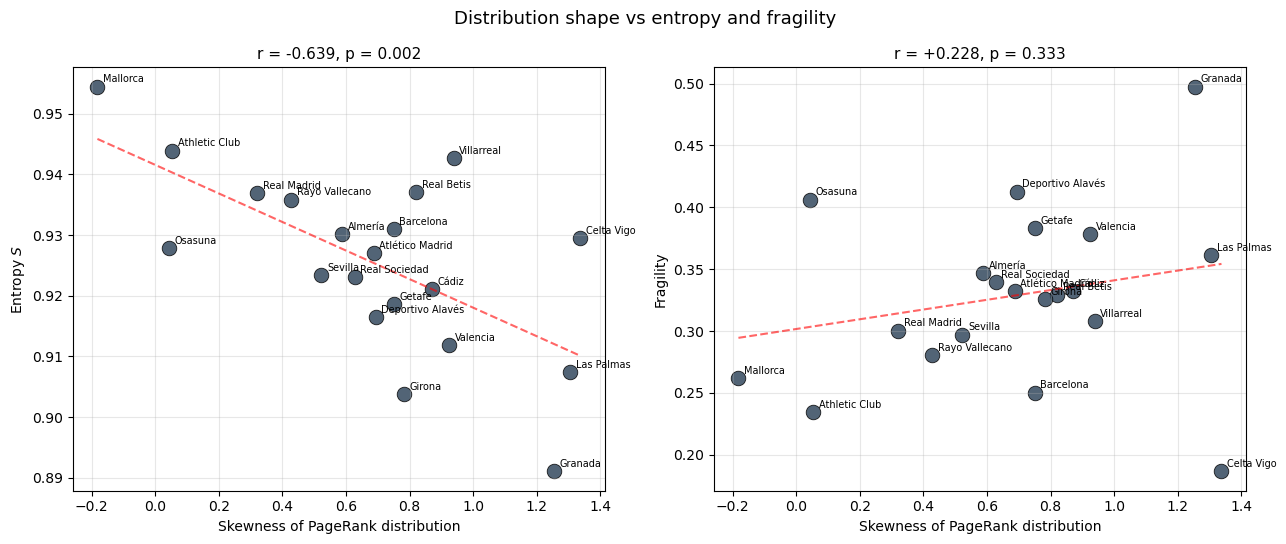

In [11]:
if 'S_pr' in df_merged.columns:
    pairs = [('skewness', 'S_pr', 'Entropy $S$'),
             ('skewness', 'fragility', 'Fragility')]
    pairs = [(a, b, lab) for a, b, lab in pairs if b in df_merged.columns]
    if pairs:
        fig, axes = plt.subplots(1, len(pairs), figsize=(6.5 * len(pairs), 5.5))
        if len(pairs) == 1:
            axes = [axes]
        for ax, (xm, ym, ylab) in zip(axes, pairs):
            sub = df_merged[[xm, ym, 'team']].dropna()
            ax.scatter(sub[xm], sub[ym], s=110, alpha=0.85, color='#34495e',
                       edgecolors='black', linewidths=0.6)
            for _, row in sub.iterrows():
                ax.annotate(row['team'], (row[xm], row[ym]), fontsize=7,
                            textcoords='offset points', xytext=(4, 3))
            m, b = np.polyfit(sub[xm], sub[ym], 1)
            xl = np.linspace(sub[xm].min(), sub[xm].max(), 100)
            ax.plot(xl, m * xl + b, 'r--', alpha=0.6)
            r, p = stats.pearsonr(sub[xm], sub[ym])
            ax.set_xlabel('Skewness of PageRank distribution', fontsize=10)
            ax.set_ylabel(ylab, fontsize=10)
            ax.set_title(f'r = {r:+.3f}, p = {p:.3f}', fontsize=11)
            ax.grid(alpha=0.3)
        plt.suptitle('Distribution shape vs entropy and fragility', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/centrality_shape_vs_entropy_fragility.png',
                    dpi=130, bbox_inches='tight')
        plt.show()

### Summary

In [12]:
print('=' * 70)
print('SUMMARY - Shape of the player centrality distribution')
print('=' * 70)
print(f"\nPooled sample: n = {len(pr_rescaled)} player-team PageRank values")
print(f"  skewness = {stats.skew(pr_rescaled):+.3f}, "
      f"excess kurtosis = {stats.kurtosis(pr_rescaled):+.3f}")
print(f"\nBest-fitting distribution (AIC): {df_fit.iloc[0]['distribution']}")
print('Full ranking:')
print(df_fit[['distribution', 'AIC', 'delta_AIC', 'KS_p']].to_string(index=False))
print(f"\nPer-team skewness range: [{df_shape['skewness'].min():.2f}, "
      f"{df_shape['skewness'].max():.2f}]")

SUMMARY - Shape of the player centrality distribution

Pooled sample: n = 607 player-team PageRank values
  skewness = +0.842, excess kurtosis = +0.249

Best-fitting distribution (AIC): gamma
Full ranking:
distribution    AIC  delta_AIC   KS_p
       gamma 1004.4        0.0 0.0000
 exponential 1020.7       16.3 0.0001
   lognormal 1155.2      150.8 0.0000
      normal 1329.6      325.2 0.0000

Per-team skewness range: [-0.18, 1.34]
